Shadow removal complete!


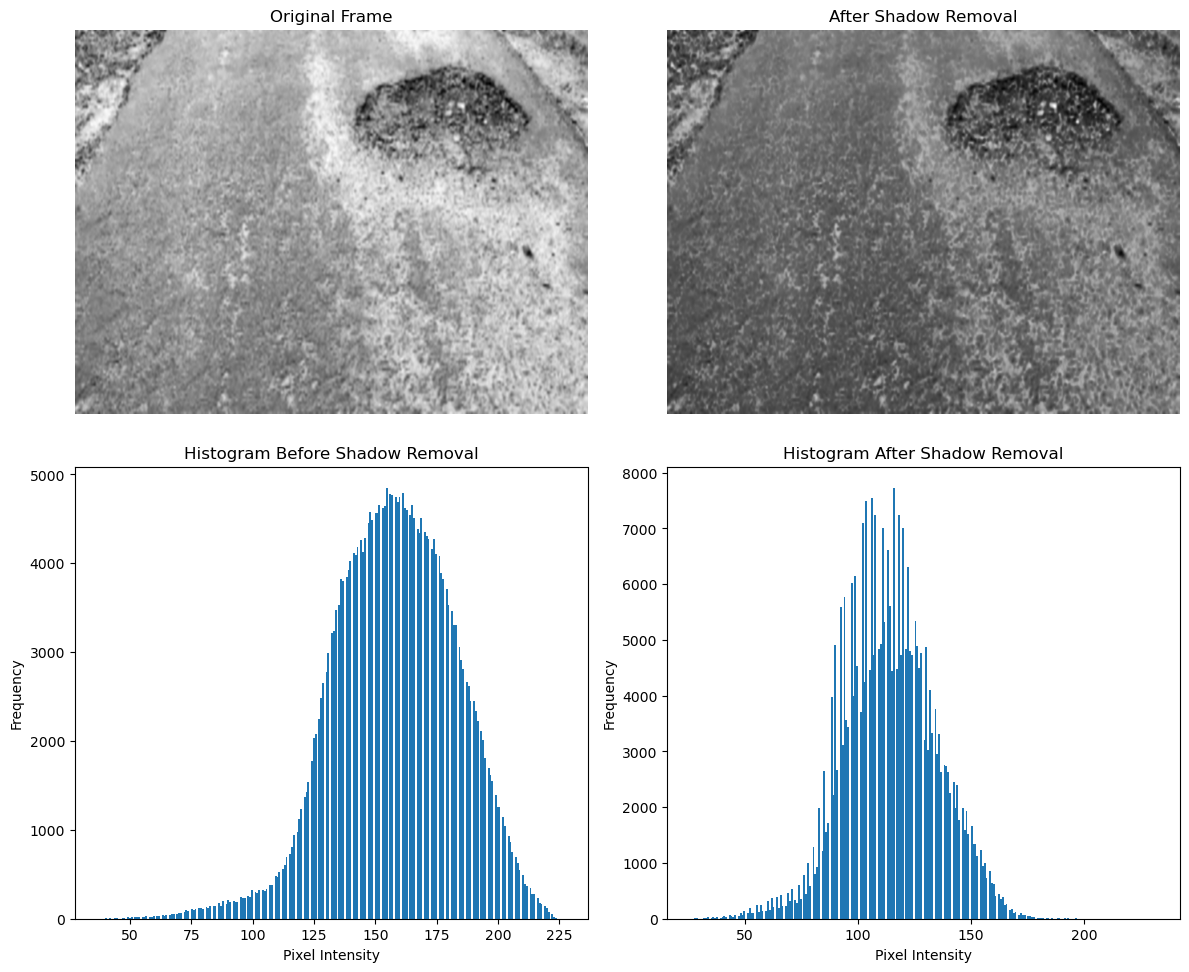

In [2]:
import cv2
import os
import numpy as np
import matplotlib.pyplot as plt

input_folder  = "denoised_checked"
output_folder = "shadow_removed"
os.makedirs(output_folder, exist_ok=True)

def remove_shadow(gray):
    illumination = cv2.GaussianBlur(gray, (51, 51), 0)
    subtracted   = cv2.subtract(gray, illumination)
    result       = cv2.normalize(subtracted, None, 0, 255, cv2.NORM_MINMAX)
    result       = cv2.addWeighted(result, 0.3, gray, 0.7, 0)
    return result

before = None
after  = None

for filename in sorted(os.listdir(input_folder)):
    gray = cv2.imread(os.path.join(input_folder, filename), cv2.IMREAD_GRAYSCALE)
    if gray is None:
        continue
    result = remove_shadow(gray)
    cv2.imwrite(os.path.join(output_folder, filename), result)
    if filename == "frame_0000.png":
        before = gray
        after  = result

print("Shadow removal complete!")

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plt.imshow(before, cmap="gray")
plt.title("Original Frame")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(after, cmap="gray")
plt.title("After Shadow Removal")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.hist(before.ravel(), bins=256)
plt.title("Histogram Before Shadow Removal")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)
plt.hist(after.ravel(), bins=256)
plt.title("Histogram After Shadow Removal")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()